# HF vs vLLM: Data-Parallel Inference Comparison

Comparing InternVL3-8B served via HuggingFace (`internvl3`) and vLLM (`internvl3-vllm`)
backends on 4x NVIDIA L4 GPUs with data-parallel dispatch (TP=1 per GPU).

Evaluated on the **LMM PoC dataset** (195 annotated document images: 93 receipts, 70 invoices,
28 bank statements, 2 travel expenses, 2 vehicle logbooks).

Three configurations:
1. **HF 4-stage**: classify + extract as separate stages (HuggingFace backend)
2. **vLLM 4-stage**: classify + extract as separate stages (vLLM backend)
3. **vLLM 3-stage**: graph-robust probe-based pipeline (classify + extract combined in one pass)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

In [2]:
# --- Raw results from pipeline runs ---
data = {
    "Config": ["HF 4-stage", "vLLM 4-stage", "vLLM 3-stage"],
    "Images Processed": [195, 195, 195],
    "Inference Time (s)": [1345.0, 1746.0, 1014.0],
    "Throughput (img/min)": [8.70, 6.70, 11.54],
    "Avg F1 (mean)": [0.656, 0.658, 0.634],
    "Avg F1 (median)": [0.847, 0.844, 0.821],
}

df = pd.DataFrame(data).set_index("Config")
df

,Images Processed,Inference Time (s),Throughput (img/min),Avg F1 (mean),Avg F1 (median)
Config,,,,,
HF 4-stage,195,1345.0,8.70,0.656,0.847
vLLM 4-stage,195,1746.0,6.70,0.658,0.844
vLLM 3-stage,195,1014.0,11.54,0.634,0.821


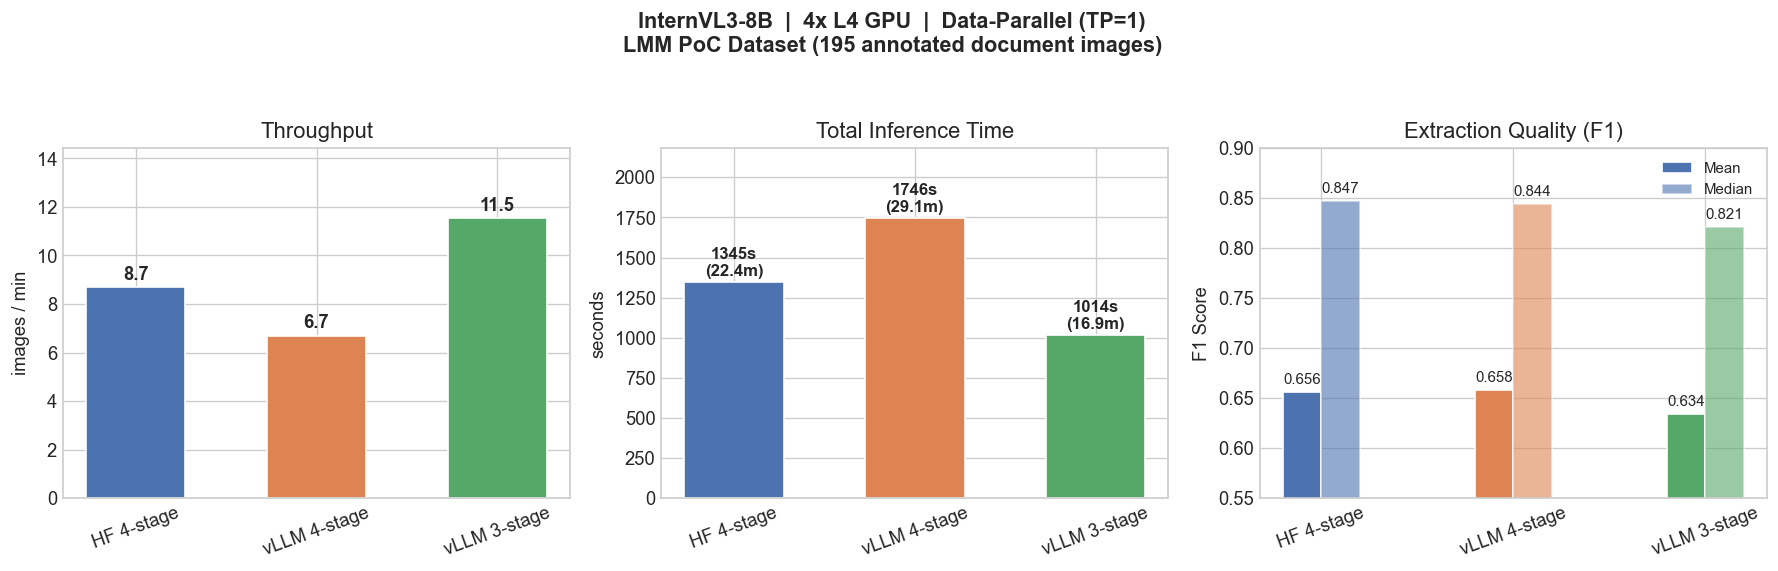

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig.suptitle(
    "InternVL3-8B  |  4x L4 GPU  |  Data-Parallel (TP=1)\n"
    "LMM PoC Dataset (195 annotated document images)",
    fontsize=13, fontweight="bold", y=1.05,
)

# --- Panel 1: Throughput ---
ax = axes[0]
bars = ax.bar(df.index, df["Throughput (img/min)"], color=colors, width=0.55, edgecolor="white")
for bar, val in zip(bars, df["Throughput (img/min)"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f"{val:.1f}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("images / min")
ax.set_title("Throughput")
ax.set_ylim(0, max(df["Throughput (img/min)"]) * 1.25)
ax.tick_params(axis="x", rotation=20)

# --- Panel 2: Inference Time ---
ax = axes[1]
bars = ax.bar(df.index, df["Inference Time (s)"], color=colors, width=0.55, edgecolor="white")
for bar, val in zip(bars, df["Inference Time (s)"]):
    minutes = val / 60
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"{val:.0f}s\n({minutes:.1f}m)", ha="center", va="bottom", fontweight="bold", fontsize=10)
ax.set_ylabel("seconds")
ax.set_title("Total Inference Time")
ax.set_ylim(0, max(df["Inference Time (s)"]) * 1.25)
ax.tick_params(axis="x", rotation=20)

# --- Panel 3: F1 Scores ---
ax = axes[2]
x = range(len(df.index))
w = 0.2
bars_mean = ax.bar([i - w/2 for i in x], df["Avg F1 (mean)"], width=w,
                   label="Mean", color=colors, edgecolor="white")
bars_med = ax.bar([i + w/2 for i in x], df["Avg F1 (median)"], width=w,
                  label="Median", color=colors, edgecolor="white", alpha=0.6)
for bar, val in zip(bars_mean, df["Avg F1 (mean)"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
for bar, val in zip(bars_med, df["Avg F1 (median)"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(list(x))
ax.set_xticklabels(df.index, rotation=20)
ax.set_ylabel("F1 Score")
ax.set_title("Extraction Quality (F1)")
ax.set_ylim(0.55, 0.9)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## Key Takeaways

| Metric | HF 4-stage | vLLM 4-stage | vLLM 3-stage | Best |
|--------|-----------|-------------|-------------|------|
| Throughput | 8.70 img/min | 6.70 img/min | **11.54 img/min** | vLLM 3-stage |
| Inference Time | 1345s (22.4m) | 1746s (29.1m) | **1014s (16.9m)** | vLLM 3-stage |
| F1 (mean) | 0.656 | **0.658** | 0.634 | vLLM 4-stage |
| F1 (median) | **0.847** | 0.844 | 0.821 | HF 4-stage |

- **Fastest**: vLLM 3-stage is 33% faster than HF 4-stage and 72% faster than vLLM 4-stage.
- **Best quality**: 4-stage pipelines (HF and vLLM) are equivalent and ~2 points higher median F1 than 3-stage.
- **Speed vs quality trade-off**: vLLM 3-stage saves 5.5 min per run but drops median F1 from 0.847 to 0.821.

## Analysis

**4-stage (HF vs vLLM)**: HF is 30% faster (8.70 vs 6.70 img/min) while F1 is effectively identical. The vLLM overhead likely comes from engine startup + continuous batching machinery that doesn't pay off in a sequential-per-worker DP setup where each GPU processes one image at a time.

**3-stage (graph-robust)**: The fastest configuration at 11.54 img/min -- it eliminates the separate classification stage by running extraction probes that simultaneously determine document type. The speed gain comes from fewer total model calls (no dedicated classification pass), but F1 drops ~2.5 points (median) because probe-based classification is less accurate than the dedicated classifier. The 2 UNKNOWN documents suggest the probes failed to identify those document types.